In [ ]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

In [ ]:
#Loading csv file
df = pd.read_csv("ChChSe-Decagon_polypharmacy.csv")

In [ ]:
df.head()

,# STITCH 1,STITCH 2,Polypharmacy Side Effect,Side Effect Name
0,CID000002173,CID000003345,C0151714,hypermagnesemia
1,CID000002173,CID000003345,C0035344,retinopathy of prematurity
2,CID000002173,CID000003345,C0004144,atelectasis
3,CID000002173,CID000003345,C0002063,alkalosis
4,CID000002173,CID000003345,C0004604,Back Ache


In [ ]:
from numpy.random.mtrand import random
# Sampling Demo the Data for clarity
sample_demo = df.sample(frac = 0.0003, random_state=42)
display(sample_demo.head())

,# STITCH 1,STITCH 2,Polypharmacy Side Effect,Side Effect Name
717038,CID000003476,CID000005523,C0032285,neumonia
540886,CID000000853,CID000003510,C0030446,adynamic ileus
2684652,CID000003333,CID000005544,C0085631,agitated
484024,CID000003325,CID000004900,C0011334,dental caries
1249512,CID000002477,CID000004542,C0038999,bulging


In [ ]:
# Add Standard Sample
sample = pd.read_csv("sample.csv")
sample.head()

,Unnamed: 0,# STITCH 1,STITCH 2,Polypharmacy Side Effect,Side Effect Name
0,1140193,CID000003032,CID006918453,C0018801,cardiac failure
1,1909223,CID000003325,CID000003419,C0018824,cardiac valvulopathy
2,1013081,CID000002471,CID000003310,C0027947,Neutropenia
3,1982248,CID000004171,CID000005391,C0006118,brain neoplasm
4,2427896,CID000000271,CID000005650,C0018099,gout


In [ ]:
# Creating Graph
G = nx.Graph()

In [ ]:
for _, row in sample.iterrows():
  drug1 = row["# STITCH 1"] # Weird naming convention
  drug2 = row["STITCH 2"]
  side_effect_id = row["Polypharmacy Side Effect"]
  side_effect_name = row["Side Effect Name"]

  # Combine ID and name

  side_effect = {
      "id": side_effect_id,
      "name": side_effect_name
  }

  # If the edge already exists, append the new side-effect
  if G.has_edge(drug1, drug2):
    G[drug1][drug2]["side_effects"].append(side_effect)
    G[drug1][drug2]["count"] += 1
  else:
    G.add_edge(drug1, drug2, side_effects=[side_effect], count=1)



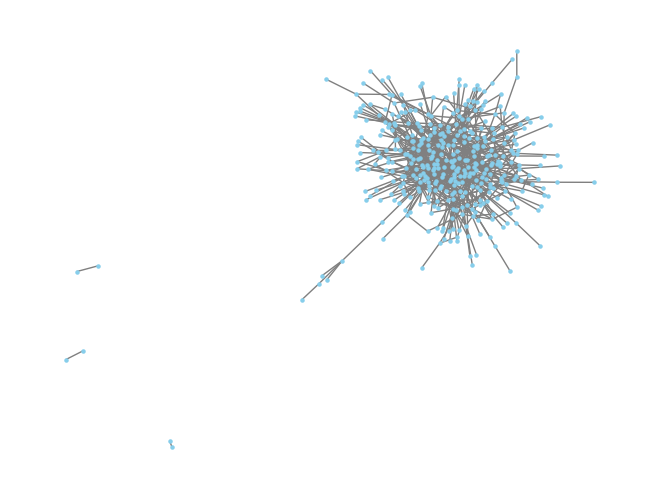

In [ ]:
nx.draw(G, node_color='skyblue', node_size=5, edge_color='gray')

Dijkstra's Algorithm


In [ ]:
# Dijkstra's algorithm
# Applying single source Dijkstra's

import heapq

def dijkstra(graph, start):
    counts = {node: float("inf") for node in graph}
    counts[start] = 0

    priorityq = [(0, start)]

    while priorityq:
        current_count, current_node = heapq.heappop(priorityq)

        if current_count > counts[current_node]:
            continue

        for neighbor, data in graph[current_node].items():
            count = data.get("count", 1)

            new_count = current_count + count

            if new_count < counts[neighbor]:
                counts[neighbor] = new_count
                heapq.heappush(priorityq, (count, neighbor))


    counts = {node: (None if value == float("inf") else value) for node, value in counts.items()}

    return counts

In [ ]:
dijkstra(G, 'CID000003032')

{'CID000003032': 0,
 'CID006918453': 1,
 'CID000003325': 2,
 'CID000003419': 2,
 'CID000002471': 2,
 'CID000003310': 2,
 'CID000004171': 2,
 'CID000005391': 2,
 'CID000000271': 2,
 'CID000005650': 2,
 'CID000000853': 2,
 'CID000002099': 2,
 'CID000002666': 2,
 'CID000005203': 2,
 'CID000002249': 1,
 'CID000004449': 2,
 'CID000002162': 2,
 'CID000002520': 2,
 'CID000000937': 2,
 'CID000003333': 2,
 'CID000004173': 2,
 'CID000005645': 2,
 'CID000003075': 2,
 'CID000003702': 2,
 'CID000003003': 2,
 'CID000004409': 2,
 'CID000002088': 2,
 'CID000005152': 2,
 'CID000003348': 2,
 'CID000005538': 2,
 'CID000004159': 2,
 'CID000054454': 2,
 'CID000005029': 2,
 'CID000002250': 2,
 'CID000002585': 2,
 'CID000002662': 2,
 'CID000004236': 2,
 'CID000004595': 2,
 'CID000003016': 2,
 'CID000004614': 2,
 'CID000004485': 2,
 'CID000004635': 2,
 'CID000130881': 2,
 'CID000002244': 2,
 'CID000005038': 2,
 'CID000064147': 2,
 'CID000000444': 2,
 'CID000003393': 2,
 'CID000002909': 2,
 'CID000003440': 2,


##Girvan Newman Algorithm

['CID000005732', 'CID000003042']


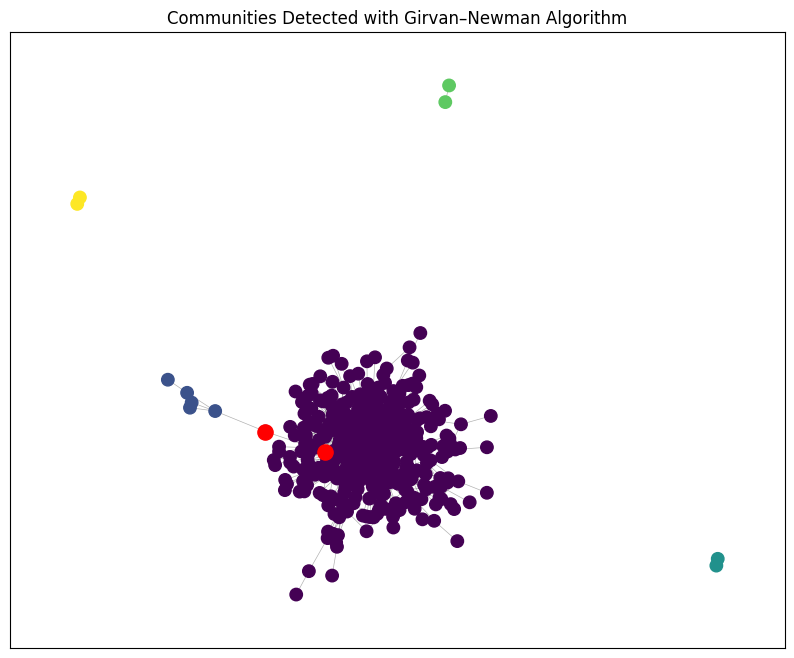

In [50]:
import matplotlib.pyplot as plt
import itertools

# Compute communities using Girvan–Newman Algorithm
communities_generator = nx.community.girvan_newman(G)

# Choose depth level, which splits the dataset into level + 1 communities tuple of sets
level = 0
communs = next(itertools.islice(communities_generator, level, None))

# Convert communs tuple of sets to a list of communities
communities = [list(c) for c in communs]

# Find community of node
node_to_comm = {}
for i, comm in enumerate(communities):
    for node in comm:
        node_to_comm[node] = i # Form dictionary of nodes that has which community it's in

# Find bridge nodes
bridge_nodes = []

for node in G.nodes():
    comm = node_to_comm[node] # Find which community the node belongs to
    for neighbor in G.neighbors(node):
        if node_to_comm[neighbor] != comm: # If node is in different community
            bridge_nodes.append(node)
            break

# Print the bridge nodes
print(bridge_nodes)

# Assign a color to each community
color_map = {}
for i, community in enumerate(communities):
    for node in community:
        color_map[node] = i

node_colors = [color_map[n] for n in G.nodes()]

bridge_set = set(bridge_nodes)

# Plot
plt.figure(figsize=(10, 8))
pos = nx.spring_layout(G, seed=42)

# Draw the nodes themselves with the color of their community
nx.draw_networkx_nodes(G, pos,
                       node_size=80,
                       node_color=node_colors)

# Draw the edges
nx.draw_networkx_edges(G, pos, alpha=0.3, width=0.5)

# Draw the bridge nodes
nx.draw_networkx_nodes(
    G, pos,
    nodelist=list(bridge_set),
    node_color="red",
    node_size=120
)

plt.title("Communities Detected with Girvan–Newman Algorithm")
plt.show()



With 2 communities, there are 2 bridge nodes:

CID000005732 - Zolpidem

CID000003042 - Dicyclomine

##Finding Highest Degree in Each Cluster

In [ ]:
# Find the node with the most edges (highest degree) in each community
highest_degree_nodes = []

for i, community in enumerate(communities):
    # Build a list of (node, degree)
    degrees = [(node, G.degree(node)) for node in community]

    # Pick the node with the maximum degree
    max_node, max_deg = max(degrees, key=lambda x: x[1])

    highest_degree_nodes.append((i, max_node, max_deg))

# Print results
for comm_id, node, deg in highest_degree_nodes:
  # Make sure you don't get any outliers
  if deg > 1:
    print(f"Community {comm_id}: highest-degree node = {node} (degree {deg})")

Community 0: highest-degree node = CID000002083 (degree 16)
Community 1: highest-degree node = CID000004889 (degree 4)


CID000002083 - Salbutamol

CID000004889 - 3,5-Dihydroxy-7-(6-hydroxy-2-methyl-8-((2-methylbutanoyl)oxy)-1,2,6,7,8,8a-hexahydronaphthalen-1-yl)heptanoic acid